In [1]:
# =========================
# 1) INSTALLATION & IMPORTS
# =========================
!pip -q install catboost optuna

import pandas as pd
import numpy as np
import re
import pickle
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
from catboost import CatBoostClassifier

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [2]:
# =========================
# 2) CONFIGURATION
# =========================
# Variables cibles et chemins
DATA_PATH = "/kaggle/input/datasets/rayenbcheikh/data-code/nv_data_historique_coherent_unique.csv" 
TARGET = "Converted"

# Listes de mots pour l'ingénierie
MOTS_INTENTION = r'\b(démo|prix|urgent|réunion|projet|intéressé|positif|priorité|budget|décision|besoin)\b'
MOTS_NEGATIFS = r'\b(pas|jamais|non|limité|partielle|fermé|indisponible|reporté|annulé)\b'

FEATURES_NUMERIQUES = [
    'TotalVisits', 
    'Total Time Spent on Website', 
    'Page Views Per Visit'
]

FEATURES_EXTRAITES = [
    'longueur_message', 
    'nb_mots_intention', 
    'nb_mots_negatifs', 
    'ratio_sentiment'
]

ALL_FEATURES = FEATURES_NUMERIQUES + FEATURES_EXTRAITES

In [3]:

# PREPROCESSING COMPLET 


import pandas as pd
import numpy as np
import re
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer


ALL_FEATURES = [
    'TotalVisits',
    'Total Time Spent on Website',
    'Page Views Per Visit',
    'longueur_message',
    'nb_mots_intention',
    'nb_mots_negatifs',
    'ratio_sentiment',
    'densite_intention',
    'engagement_score',
]

def engineer_features(df, scaler=None, imputer=None, fit=True):
    temp_df = df.copy()

    # =========================================================
    # BLOC 0 — LOG DES ANOMALIES + DOUBLONS + DÉTECTION OUTLIERS
    # =========================================================
    print("=" * 55)
    print("📋 RAPPORT  DES DONNÉES BRUTES")
    print("=" * 55)
    print(f"📊 Lignes totales          : {len(temp_df)}")

    n_doublons = temp_df.duplicated().sum()
    print(f"🔁 Doublons détectés       : {n_doublons}")

    n_nan_total = temp_df[FEATURES_NUMERIQUES].isnull().sum().sum()
    print(f"❓ Valeurs manquantes (num): {n_nan_total}")

    for col in FEATURES_NUMERIQUES:
        n_nan_col = temp_df[col].isnull().sum()
        if n_nan_col > 0:
            print(f"   └─ {col} : {n_nan_col} NaN ({n_nan_col/len(temp_df)*100:.1f}%)")

    n_msg_vides = temp_df['historique_message'].isnull().sum()
    print(f"💬 Messages vides          : {n_msg_vides}")
    print("-" * 55)

    print("🔍 DÉTECTION DES OUTLIERS (méthode IQR)")
    print("-" * 55)

    outlier_report = {}

    for col in FEATURES_NUMERIQUES:
        serie = pd.to_numeric(temp_df[col], errors='coerce').dropna()

        Q1 = serie.quantile(0.25)
        Q3 = serie.quantile(0.75)
        IQR = Q3 - Q1

        borne_basse = Q1 - 1.5 * IQR
        borne_haute = Q3 + 1.5 * IQR

        outliers_bas = (serie < borne_basse).sum()
        outliers_haut = (serie > borne_haute).sum()
        n_outliers = outliers_bas + outliers_haut

        outlier_report[col] = {
            'n_outliers': n_outliers,
            'borne_haute': round(borne_haute, 2),
            'valeur_max': round(serie.max(), 2),
        }

        statut = "⚠️ " if n_outliers > 0 else "✅"

        print(f"{statut} {col}")
        print(f"   ├─ Plage normale  : [{borne_basse:.1f} ; {borne_haute:.1f}]")
        print(f"   ├─ Plage réelle   : [{serie.min():.1f} ; {serie.max():.1f}]")
        print(f"   ├─ Médiane        : {serie.median():.1f}")
        print(f"   ├─ Outliers bas   : {outliers_bas}")
        print(f"   └─ Outliers haut  : {outliers_haut} → total : {n_outliers} ({n_outliers/len(serie)*100:.1f}%)")
        print()

    for col, stats in outlier_report.items():
        pct = stats['n_outliers'] / len(temp_df) * 100
        if pct > 5:
            print(f"🚨 ALERTE : {col} a {pct:.1f}% d'outliers — vérifier la qualité des données !")

    print("=" * 55)

    # 0.4 — DOUBLONS : DÉTECTION 
    print(f"🔁 Doublons détectés  : {n_doublons}")
   
    print("=" * 55)

    # =========================================================
    # BLOC A — NETTOYAGE DU TEXTE BRUT
    # =========================================================
    temp_df['historique_message'] = (
        temp_df['historique_message']
        .fillna('')
        .str.lower()
        .str.strip()
        .str.replace(r'\s+', ' ', regex=True)
    )

    # =========================================================
    # BLOC B — NETTOYAGE DES COLONNES NUMÉRIQUES
    # =========================================================
    for col in FEATURES_NUMERIQUES:
        temp_df[col] = pd.to_numeric(temp_df[col], errors='coerce')

    if fit:
        imputer = SimpleImputer(strategy='median')
        temp_df[FEATURES_NUMERIQUES] = imputer.fit_transform(temp_df[FEATURES_NUMERIQUES])
    else:
        temp_df[FEATURES_NUMERIQUES] = imputer.transform(temp_df[FEATURES_NUMERIQUES])

    temp_df['TotalVisits'] = temp_df['TotalVisits'].clip(upper=20)
    temp_df['Page Views Per Visit'] = temp_df['Page Views Per Visit'].clip(upper=12)

    # =========================================================
    # BLOC C — FEATURE ENGINEERING TEXTE
    # =========================================================
    temp_df['longueur_message'] = temp_df['historique_message'].str.len()
    temp_df['nb_mots_intention'] = temp_df['historique_message'].str.count(MOTS_INTENTION)
    temp_df['nb_mots_negatifs'] = temp_df['historique_message'].str.count(MOTS_NEGATIFS)

    temp_df['ratio_sentiment'] = (
        (temp_df['nb_mots_intention'] + 1) /
        (temp_df['nb_mots_negatifs'] + 1)
    )

    temp_df['nb_mots'] = temp_df['historique_message'].str.split().str.len().fillna(0)

    temp_df['densite_intention'] = (
        temp_df['nb_mots_intention'] / (temp_df['nb_mots'] + 1)
    )

    

    # =========================================================
    # BLOC D — FEATURE CROISÉE
    # =========================================================
    temp_df['engagement_score'] = (
        temp_df['TotalVisits'] * temp_df['Total Time Spent on Website']
    )

    # =========================================================
    # BLOC E — NORMALISATION
    # =========================================================
    if fit:
        scaler = RobustScaler()
        temp_df[FEATURES_NUMERIQUES] = scaler.fit_transform(temp_df[FEATURES_NUMERIQUES])
    else:
        temp_df[FEATURES_NUMERIQUES] = scaler.transform(temp_df[FEATURES_NUMERIQUES])

    # =========================================================
    # BLOC F — VALIDATION
    # =========================================================
    assert temp_df[ALL_FEATURES].isnull().sum().sum() == 0, \
        "❌ Il reste des NaN après preprocessing."

    assert (temp_df['ratio_sentiment'] >= 0).all(), \
        "❌ ratio_sentiment contient des valeurs négatives."

    assert (temp_df['engagement_score'] >= 0).all(), \
        "❌ engagement_score contient des valeurs négatives."

    print(f"✅ Preprocessing terminé — {len(temp_df)} lignes | {len(ALL_FEATURES)} features")

    return temp_df[ALL_FEATURES], scaler, imputer


def prepare_data(df, scaler=None, imputer=None, fit=True):
    X, scaler, imputer = engineer_features(df, scaler=scaler, imputer=imputer, fit=fit)
    y = df['Converted'].astype(int)
    return X, y, scaler, imputer

print(

In [4]:
# =========================
# 4) PIPELINE D'ENTRAINEMENT 
# =========================
def train_model(X_train, X_test, y_train, y_test):
    
    model = CatBoostClassifier(
        iterations=500,
        learning_rate=0.05,
        depth=6,
        l2_leaf_reg=3,
        eval_metric='AUC',
        verbose=100,
        random_seed=42
    )

    model.fit(X_train, y_train, eval_set=(X_test, y_test), early_stopping_rounds=50)
    
    # Evaluation
    probs = model.predict_proba(X_test)[:, 1]
    print(f"\n✅ Entraînement terminé. ROC AUC réel : {roc_auc_score(y_test, probs):.4f}")
    
    return model

In [5]:
# =========================
# 5) EXECUTION 
# =========================
from sklearn.model_selection import train_test_split

try:
    # 1. Charger le CSV 
    raw_df = pd.read_csv("/kaggle/input/datasets/rayenbcheikh/data-code/nv_data_historique_coherent_unique.csv")
    
    # 2. SÉPARATION IMMÉDIATE (Avant tout calcul de médiane ou d'échelle)
    train_df, test_df = train_test_split(raw_df, test_size=0.2, random_state=42, stratify=raw_df['Converted'])

    print("--- Préparation du jeu d'Entraînement ---")
    # 3. FIT = TRUE : Le modèle apprend les échelles et médianes sur le Train
    X_train, y_train, scaler_entrainement, imputer_entrainement = prepare_data(train_df, fit=True)

    print("\n--- Préparation du jeu de Test ---")
    # 4. FIT = FALSE : On applique les échelles du Train au Test 
    X_test, y_test, _, _ = prepare_data(test_df, scaler=scaler_entrainement, imputer=imputer_entrainement, fit=False)

    # 5. Entraînement du modèle
    model = train_model(X_train, X_test, y_train, y_test)

    # 6. Afficher l'importance des variables
    importance_df = pd.DataFrame({
        'Feature': ALL_FEATURES,
        'Importance': model.get_feature_importance()
    }).sort_values(by='Importance', ascending=False)

    print("\n=== IMPORTANCE DES VARIABLES ===")
    print(importance_df)

except Exception as e:
    print(f"Erreur : {e}.")

--- Préparation du jeu d'Entraînement ---
📋 RAPPORT  DES DONNÉES BRUTES
📊 Lignes totales          : 7392
🔁 Doublons détectés       : 0
❓ Valeurs manquantes (num): 0
💬 Messages vides          : 0
-------------------------------------------------------
🔍 DÉTECTION DES OUTLIERS (méthode IQR)
-------------------------------------------------------
⚠️  TotalVisits
   ├─ Plage normale  : [-5.0 ; 11.0]
   ├─ Plage réelle   : [0.0 ; 251.0]
   ├─ Médiane        : 3.0
   ├─ Outliers bas   : 0
   └─ Outliers haut  : 320 → total : 320 (4.3%)

✅ Total Time Spent on Website
   ├─ Plage normale  : [-1372.9 ; 2320.1]
   ├─ Plage réelle   : [0.0 ; 2272.0]
   ├─ Médiane        : 251.0
   ├─ Outliers bas   : 0
   └─ Outliers haut  : 0 → total : 0 (0.0%)

⚠️  Page Views Per Visit
   ├─ Plage normale  : [-2.8 ; 7.2]
   ├─ Plage réelle   : [0.0 ; 55.0]
   ├─ Médiane        : 2.0
   ├─ Outliers bas   : 0
   └─ Outliers haut  : 284 → total : 284 (3.8%)

🔁 Doublons détectés  : 0
✅ Preprocessing terminé — 7392 

=== PERFORMANCES SUR LE JEU DE TEST ===
Précision (Accuracy) : 82.58 %
Score ROC AUC        : 90.52 %

=== RAPPORT DE CLASSIFICATION ===
              precision    recall  f1-score   support

           0       0.85      0.87      0.86      1136
           1       0.78      0.76      0.77       712

    accuracy                           0.83      1848
   macro avg       0.82      0.81      0.81      1848
weighted avg       0.82      0.83      0.83      1848



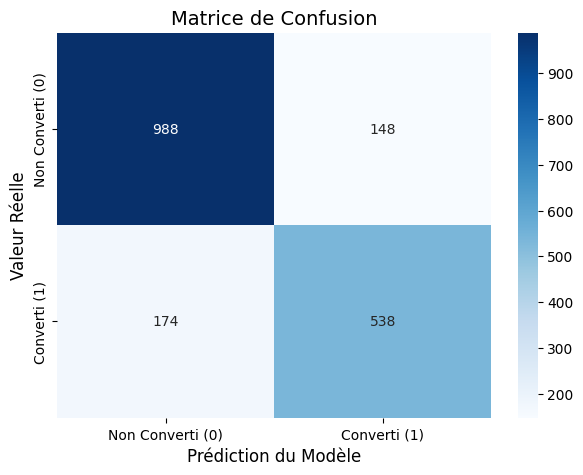


=== APERÇU CONCRET DE 10 LEADS ===


,Vrai_Statut (Réalité),Classe_Predite (Modèle),Score_Probabilité
8082,1,0,31.85 %
5107,0,0,0.5 %
4704,0,0,5.65 %
7161,0,1,70.1 %
3095,1,1,96.49 %
7779,0,0,11.61 %
8157,0,0,24.69 %
248,0,0,23.0 %
111,1,1,91.21 %
8139,0,0,2.41 %


In [6]:
# =========================
# 6) ANALYSE DÉTAILLÉE DES RÉSULTATS
# =========================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from IPython.display import display

# 1. Calcul des prédictions sur le jeu de test
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# 2. Affichage des métriques globales
print("=== PERFORMANCES SUR LE JEU DE TEST ===")
print(f"Précision (Accuracy) : {accuracy_score(y_test, y_pred) * 100:.2f} %")
print(f"Score ROC AUC        : {roc_auc_score(y_test, y_proba) * 100:.2f} %")
print("\n=== RAPPORT DE CLASSIFICATION ===")
print(classification_report(y_test, y_pred))

# 3. Affichage de la Matrice de Confusion
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Non Converti (0)', 'Converti (1)'], 
            yticklabels=['Non Converti (0)', 'Converti (1)'])
plt.title('Matrice de Confusion', fontsize=14)
plt.xlabel('Prédiction du Modèle', fontsize=12)
plt.ylabel('Valeur Réelle', fontsize=12)
plt.show()

# 4. Aperçu concret des prédictions (10 exemples aléatoires)
print("\n=== APERÇU CONCRET DE 10 LEADS ===")
results_df = X_test.copy()
results_df['Vrai_Statut (Réalité)'] = y_test
results_df['Classe_Predite (Modèle)'] = y_pred
results_df['Score_Probabilité'] = np.round(y_proba * 100, 2).astype(str) + " %"

# On affiche un échantillon de 10 lignes pour voir concrètement le résultat
display(results_df[['Vrai_Statut (Réalité)', 'Classe_Predite (Modèle)', 'Score_Probabilité']].sample(10, random_state=42))

In [16]:
# =========================
# 7) SEGMENTATION DES LEADS (HOT / WARM / COLD)
# =========================

# On travaille sur le jeu de test pour visualiser la répartition
df_scoring = X_test.copy()
df_scoring['Vrai_Statut'] = y_test # Pour comparer plus tard si besoin

# 1. Calcul du score de probabilité (de 0 à 100%)
df_scoring['Score_Probabilite (%)'] = np.round(model.predict_proba(X_test)[:, 1] * 100, 1)

# 2. Définition des seuils (Thresholds)
SEUIL_HOT = 83.0
SEUIL_WARM = 25.0

def categoriser_lead(score):
    if score >= SEUIL_HOT:
        return '🔥 HOT (Priorité absolue - Appeler !)'
    elif score >= SEUIL_WARM:
        return '☀️ WARM (Nurturing Marketing)'
    else:
        return '❄️ COLD (Ignorer)'

# 3. Application de la règle à notre base de données
df_scoring['Categorie'] = df_scoring['Score_Probabilite (%)'].apply(categoriser_lead)

# 4. Affichage des résultats globaux
print("=== RÉPARTITION DES LEADS ===")
repartition = df_scoring['Categorie'].value_counts()
print(repartition)
print("\n" + "-"*50 + "\n")

# 5. Aperçu de 10 leads au hasard pour voir le résultat concret
print("=== APERÇU DE 10 LEADS SCORÉS ===")
display(df_scoring[['Score_Probabilite (%)', 'Categorie', 'Vrai_Statut']].sample(10, random_state=42))



=== RÉPARTITION DES LEADS ===
Categorie
❄️ COLD (Ignorer)                       886
☀️ WARM (Nurturing Marketing)           656
🔥 HOT (Priorité absolue - Appeler !)    306
Name: count, dtype: int64

--------------------------------------------------

=== APERÇU DE 10 LEADS SCORÉS ===


,Score_Probabilite (%),Categorie,Vrai_Statut
8082,31.8,☀️ WARM (Nurturing Marketing),1
5107,0.5,❄️ COLD (Ignorer),0
4704,5.7,❄️ COLD (Ignorer),0
7161,70.1,☀️ WARM (Nurturing Marketing),0
3095,96.5,🔥 HOT (Priorité absolue - Appeler !),1
7779,11.6,❄️ COLD (Ignorer),0
8157,24.7,❄️ COLD (Ignorer),0
248,23.0,❄️ COLD (Ignorer),0
111,91.2,🔥 HOT (Priorité absolue - Appeler !),1
8139,2.4,❄️ COLD (Ignorer),0


In [8]:
# =========================
# 8)  PRÉCISION SUR LES LEADS "HOT"
# =========================

hot_leads = df_scoring[df_scoring['Score_Probabilite (%)'] >= 83.0]

# 2. On vérifie qu'il y a bien des leads HOT pour éviter une erreur de division par zéro
if len(hot_leads) > 0:
    total_hot = len(hot_leads)
    
    # On compte combien parmi eux ont réellement converti (Vrai_Statut == 1)
    vrais_convertis = hot_leads['Vrai_Statut'].sum()
    
    # Calcul de la précision
    precision_hot = (vrais_convertis / total_hot) * 100
    
    print("=== BILAN POUR L'ÉQUIPE COMMERCIALE ===")
    print(f"🔥 Nombre de leads détectés comme HOT : {total_hot}")
    print(f"✅ Nombre de ces leads qui ont VRAIMENT signé : {vrais_convertis}")
    print("-" * 40)
    print(f"🎯 PRÉCISION SUR LES LEADS HOT : {precision_hot:.2f} %")
   

=== BILAN POUR L'ÉQUIPE COMMERCIALE ===
🔥 Nombre de leads détectés comme HOT : 306
✅ Nombre de ces leads qui ont VRAIMENT signé : 272
----------------------------------------
🎯 PRÉCISION SUR LES LEADS HOT : 88.89 %


In [9]:
# =========================
# 9) FOCUS : PRÉCISION SUR LES LEADS "COLD"
# =========================

# 1. On isole uniquement les leads classés comme "COLD" 
cold_leads = df_scoring[df_scoring['Score_Probabilite (%)'] < 25.0]

if len(cold_leads) > 0:
    total_cold = len(cold_leads)
    
    # On compte combien parmi eux n'ont effectivement PAS converti (Vrai_Statut == 0)
    vrais_non_convertis = len(cold_leads[cold_leads['Vrai_Statut'] == 0])
    
    # Calcul de la précision COLD
    precision_cold = (vrais_non_convertis / total_cold) * 100
    
    print("=== BILAN DE SÉCURITÉ (LEADS COLD) ===")
    print(f"❄️ Nombre de leads détectés comme COLD : {total_cold}")
    print(f"✅ Nombre de leads qui n'ont BIEN PAS signé : {vrais_non_convertis}")
    print(f"⚠️ Nombre d'erreurs (Acheteurs ratés) : {total_cold - vrais_non_convertis}")
    print("-" * 40)
    print(f"🎯 PRÉCISION SUR LES LEADS COLD : {precision_cold:.2f} %")
    
   

=== BILAN DE SÉCURITÉ (LEADS COLD) ===
❄️ Nombre de leads détectés comme COLD : 886
✅ Nombre de leads qui n'ont BIEN PAS signé : 822
⚠️ Nombre d'erreurs (Acheteurs ratés) : 64
----------------------------------------
🎯 PRÉCISION SUR LES LEADS COLD : 92.78 %


In [27]:
# =========================
# 8) AFFICHER 10 LEADS DE CHAQUE TYPE AVEC DONNÉES BRUTES
# =========================

import pandas as pd

# Chercher automatiquement les DataFrames disponibles
dfs_disponibles = {
    name: obj for name, obj in globals().items()
    if isinstance(obj, pd.DataFrame)
}

print("DataFrames disponibles :")
print(list(dfs_disponibles.keys()))

# Choisir automatiquement la data brute :
# on évite X_train, X_test, df_scoring...
candidats = {
    name: df for name, df in dfs_disponibles.items()
    if name not in ['X_train', 'X_test', 'y_train', 'y_test', 'df_scoring']
    and len(df) >= len(X_test)
}

if len(candidats) == 0:
    raise ValueError("Aucune data brute trouvée. Vérifie le nom de ton DataFrame original.")

nom_df_original = list(candidats.keys())[0]
df_original = candidats[nom_df_original].copy()

print(f"\nData brute utilisée : {nom_df_original}")
print(f"Shape data brute : {df_original.shape}")

# Récupérer les lignes brutes correspondant au jeu de test
df_brut_scoring = df_original.loc[X_test.index].copy()

# Ajouter score + catégorie + vrai statut
df_brut_scoring['Score_Probabilite (%)'] = df_scoring['Score_Probabilite (%)'].values
df_brut_scoring['Categorie'] = df_scoring['Categorie'].values
df_brut_scoring['Vrai_Statut'] = y_test.values

# Afficher 10 leads bruts de chaque catégorie
for categorie in df_brut_scoring['Categorie'].unique():
    print("\n" + "="*120)
    print(f"=== 10 LEADS BRUTS ALÉATOIRES : {categorie} ===")
    print("="*120)

    leads_categorie = df_brut_scoring[df_brut_scoring['Categorie'] == categorie]
    n = min(10, len(leads_categorie))

    display(
        leads_categorie
        .sample(n=n, random_state=42)
        .sort_values(by='Score_Probabilite (%)', ascending=False)
    )

DataFrames disponibles :
['raw_df', 'train_df', 'test_df', 'X_train', 'X_test', 'importance_df', 'results_df', 'df_scoring', 'hot_leads', 'cold_leads', '_12', 'leads_categorie']

Data brute utilisée : raw_df
Shape data brute : (9240, 38)

=== 10 LEADS BRUTS ALÉATOIRES : ☀️ WARM (Nurturing Marketing) ===


,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,...,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity,historique_message,Score_Probabilite (%),Categorie,Vrai_Statut
841,6a3f82ae-67e0-4208-9959-d667af6b605b,651611,Lead Add Form,Reference,No,No,1,0.0,0,0.00,...,01.High,15.0,18.0,No,No,Modified,La prise de contact a permis d'identifier des ...,78.7,☀️ WARM (Nurturing Marketing),1
8874,6b5b460e-9f7f-4806-8211-56490812407a,582230,API,Olark Chat,No,No,1,0.0,0,0.00,...,02.Medium,15.0,16.0,No,No,Modified,L'échange a porté sur les enjeux généraux de l...,69.4,☀️ WARM (Nurturing Marketing),1
3744,c7c32251-7a24-462f-b778-3147f301818c,624317,API,Olark Chat,No,No,0,0.0,0,0.00,...,44,44.0,44.0,No,No,Modified,L'échange a porté sur les enjeux généraux de l...,56.7,☀️ WARM (Nurturing Marketing),0
8622,4d1d37bc-e810-448e-8657-744b33fc2b52,583946,Landing Page Submission,Direct Traffic,No,No,1,2.0,129,2.00,...,01.High,15.0,18.0,No,Yes,Email Opened,La prise de contact a permis d'identifier des ...,49.8,☀️ WARM (Nurturing Marketing),1
3035,8119b6a1-1a59-4aec-9a28-86cdc81609d6,630773,Landing Page Submission,Google,No,No,0,5.0,1049,5.00,...,44,44.0,44.0,No,No,SMS Sent,Le premier contact a donné une vision partiell...,45.2,☀️ WARM (Nurturing Marketing),0
1348,55cc76e6-a248-43cc-a095-ff0096bd233a,645713,API,Olark Chat,No,No,0,0.0,0,0.00,...,02.Medium,17.0,15.0,No,No,Modified,La discussion a permis de mieux situer le beso...,39.9,☀️ WARM (Nurturing Marketing),0
6418,6e34ec24-6cce-405b-ab9d-86ab9a828df6,600736,Landing Page Submission,Direct Traffic,No,No,1,11.0,608,2.75,...,44,44.0,44.0,No,Yes,Page Visited on Website,Le prospect a présenté brièvement son environn...,38.3,☀️ WARM (Nurturing Marketing),1
5798,c65932a8-9c21-4a58-b1f9-3e2928153de6,605295,Landing Page Submission,Google,No,No,0,9.0,367,2.25,...,44,44.0,44.0,No,No,Email Link Clicked,Un point de qualification a été effectué avec ...,38.0,☀️ WARM (Nurturing Marketing),0
1188,109e8c51-09a2-4af0-8542-b80098a632c3,647423,API,Referral Sites,No,No,1,10.0,325,3.33,...,02.Medium,15.0,16.0,No,Yes,Unreachable,Le prospect a présenté brièvement son environn...,33.0,☀️ WARM (Nurturing Marketing),1
1997,528e9c7c-0cd1-448b-b41b-c23b98f97941,640331,Landing Page Submission,Google,No,No,0,3.0,1730,3.00,...,01.High,13.0,18.0,No,No,Email Opened,L'échange a porté sur les enjeux généraux de l...,32.0,☀️ WARM (Nurturing Marketing),0



=== 10 LEADS BRUTS ALÉATOIRES : 🔥 HOT (Priorité absolue - Appeler !) ===


,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,...,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity,historique_message,Score_Probabilite (%),Categorie,Vrai_Statut
5952,25f06e4f-6563-44e7-a246-dd3ed0428e5d,604199,Landing Page Submission,Google,No,No,1,14.0,1442,2.8,...,01.High,16.0,20.0,No,Yes,Olark Chat Conversation,Le prospect a expliqué certains objectifs liés...,99.5,🔥 HOT (Priorité absolue - Appeler !),1
1557,af964fca-a43b-4aad-bfba-e70f12b88505,643946,API,Google,No,No,1,4.0,1245,2.0,...,02.Medium,15.0,16.0,No,No,SMS Sent,Le prospect a présenté brièvement son environn...,99.0,🔥 HOT (Priorité absolue - Appeler !),1
3777,0e717927-85c1-4a6e-94cb-12b78defe7e6,623925,Landing Page Submission,Direct Traffic,Yes,No,1,4.0,1040,4.0,...,44,44.0,44.0,No,Yes,SMS Sent,Le prospect a présenté brièvement son environn...,98.0,🔥 HOT (Priorité absolue - Appeler !),1
5961,ea97cd74-5a24-41b5-8a6f-374b18055ca7,604114,API,Olark Chat,No,No,1,0.0,0,0.0,...,44,44.0,44.0,No,No,SMS Sent,La prise de contact a permis d'identifier des ...,97.6,🔥 HOT (Priorité absolue - Appeler !),1
9084,d8b8e1d7-6df8-401c-92fb-399ae19aaa3c,580725,Landing Page Submission,Google,No,No,1,4.0,1172,4.0,...,02.Medium,14.0,16.0,No,No,SMS Sent,Le contact a partagé quelques informations sur...,97.1,🔥 HOT (Priorité absolue - Appeler !),1
1574,27bff521-8875-4558-9cbc-763cbecde2b9,643871,Lead Add Form,Reference,No,No,1,44.0,759,44.0,...,01.High,14.0,19.0,No,No,Modified,Un échange commercial a été réalisé avec le pr...,95.5,🔥 HOT (Priorité absolue - Appeler !),1
5330,e5b80ec7-8531-437a-9af4-361f87733afd,608929,Landing Page Submission,Organic Search,No,No,1,6.0,1578,3.0,...,02.Medium,15.0,13.0,No,Yes,Email Opened,Le prospect a expliqué certains objectifs liés...,95.0,🔥 HOT (Priorité absolue - Appeler !),1
6482,20942139-3b28-4f72-b21b-e4bf2379a839,600156,API,Olark Chat,No,No,1,0.0,0,0.0,...,44,44.0,44.0,No,No,Email Opened,Le prospect a expliqué certains objectifs liés...,89.7,🔥 HOT (Priorité absolue - Appeler !),1
6624,0512b0bd-ff9d-4e1d-8111-21a38758c651,598962,Landing Page Submission,Organic Search,No,No,1,3.0,1080,1.5,...,44,44.0,44.0,No,Yes,SMS Sent,L'échange a porté sur les enjeux généraux de l...,87.7,🔥 HOT (Priorité absolue - Appeler !),1
7851,da98bba6-75ba-4ccc-9363-762f061870cf,589558,Landing Page Submission,Google,No,No,1,5.0,1255,2.5,...,01.High,14.0,18.0,No,No,Modified,La conversation a permis de recueillir plusieu...,86.2,🔥 HOT (Priorité absolue - Appeler !),1



=== 10 LEADS BRUTS ALÉATOIRES : ❄️ COLD (Ignorer) ===


,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,...,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity,historique_message,Score_Probabilite (%),Categorie,Vrai_Statut
3640,7bfafb1d-56f5-4809-9c59-7175e53b3cf5,625541,Landing Page Submission,Google,No,No,0,4.0,208,4.0,...,44,44.0,44.0,No,No,Email Opened,Le prospect a présenté brièvement son environn...,15.7,❄️ COLD (Ignorer),0
5749,c20257e5-a6ec-4890-8fae-078b352adfa8,605656,Landing Page Submission,Direct Traffic,No,No,0,2.0,866,2.0,...,44,44.0,44.0,No,No,Email Opened,Le prospect a expliqué certains objectifs liés...,13.6,❄️ COLD (Ignorer),0
2218,83609d31-0b4e-4d19-bfd7-63895b65b7ac,638283,Landing Page Submission,Organic Search,No,No,0,3.0,291,3.0,...,02.Medium,15.0,14.0,No,Yes,Modified,L'échange a porté sur les enjeux généraux de l...,12.0,❄️ COLD (Ignorer),0
9123,fc96043b-639a-4849-9d24-05f266669d36,580429,Landing Page Submission,Direct Traffic,No,No,0,2.0,290,2.0,...,01.High,14.0,19.0,No,Yes,Email Opened,Le prospect a présenté brièvement son environn...,9.8,❄️ COLD (Ignorer),0
4978,820e6580-ab85-43a8-a72d-af29cefad8c0,612152,Landing Page Submission,Google,No,No,0,4.0,1123,4.0,...,44,44.0,44.0,No,No,SMS Sent,Le premier contact a donné une vision partiell...,5.5,❄️ COLD (Ignorer),0
8168,23678f51-35e0-4d39-825c-174335c48f69,587472,Landing Page Submission,Organic Search,No,No,0,13.0,246,6.5,...,02.Medium,16.0,13.0,No,Yes,SMS Sent,Le prospect a expliqué certains objectifs liés...,4.7,❄️ COLD (Ignorer),0
5256,910346ae-7942-4a36-a1e3-f1a39caded49,609464,API,Google,No,No,0,3.0,248,3.0,...,44,44.0,44.0,No,No,SMS Sent,Un échange commercial a été réalisé avec le pr...,3.7,❄️ COLD (Ignorer),0
8153,2011161b-5a78-4109-889a-3d1f15126e2c,587535,API,Olark Chat,No,No,0,0.0,0,0.0,...,02.Medium,16.0,15.0,No,No,Modified,La discussion a permis de mieux situer le beso...,1.8,❄️ COLD (Ignorer),0
8529,39ec53e4-f477-4ed7-ad7c-022269c70405,584599,Landing Page Submission,Google,No,No,0,5.0,4,5.0,...,01.High,13.0,17.0,No,No,SMS Sent,La discussion a permis de mieux situer le beso...,1.3,❄️ COLD (Ignorer),0
3949,a458afec-4a95-4d42-a8a5-e3b7435b32bf,622227,API,Olark Chat,No,No,0,0.0,0,0.0,...,44,44.0,44.0,No,No,Modified,Le prospect a expliqué certains objectifs liés...,0.3,❄️ COLD (Ignorer),0
